# American Option Risk Management with a CRR Tree

This notebook is the next step after the introductory American-option CRR model. It keeps valuation transparent and adds controls needed for risk work:

- step-convergence testing;
- early-exercise boundary extraction;
- position-scaled Delta, Gamma, Vega, Rho, dividend sensitivity, and Theta;
- Greek stability checks across tree sizes and bump sizes;
- full-revaluation stress scenarios;
- Greek P&L explain versus full revaluation;
- portfolio aggregation and theoretical validation.

> **Data status:** all inputs below are illustrative. Real market data is not required to run or validate the framework, but calibrated curves, dividends, volatility surfaces, and positions are required before production use.


In [1]:
from dataclasses import dataclass, replace
import math
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.display.float_format = lambda x: f'{x:,.6f}'

## 1. Contracts, market inputs, positions, and conventions

The tree price is stored **per unit of underlying**. Position PV and risk are then scaled by:

`quantity × contract multiplier`.

Rates, dividend yields, and volatility are decimal annualized inputs. Thus 5% is entered as `0.05`, one volatility point is `0.01`, and one basis point is `0.0001`. Theta below means the P&L from one calendar day passing while other market inputs remain unchanged.


In [2]:
@dataclass(frozen=True)
class OptionContract:
    strike: float
    maturity: float  # years from valuation date
    option_type: Literal['call', 'put']
    style: Literal['american', 'european'] = 'american'
    multiplier: float = 100.0

    def intrinsic(self, spot):
        sign = 1.0 if self.option_type.lower() == 'call' else -1.0
        return np.maximum(sign * (np.asarray(spot, dtype=float) - self.strike), 0.0)


@dataclass(frozen=True)
class MarketData:
    spot: float
    rate: float             # continuously compounded risk-free rate
    dividend_yield: float   # continuous dividend yield
    volatility: float       # annualized volatility


@dataclass(frozen=True)
class TreeConfig:
    steps: int = 500
    exercise_tolerance: float = 1e-12


@dataclass(frozen=True)
class Position:
    name: str
    option: OptionContract
    quantity: float = 1.0  # positive long, negative short

    @property
    def scale(self):
        return self.quantity * self.option.multiplier


@dataclass
class TreeResult:
    unit_price: float
    probability_up: float
    up_factor: float
    down_factor: float
    stock_nodes: list
    value_nodes: list
    exercise_nodes: list


@dataclass(frozen=True)
class RiskBumps:
    spot_relative: float = 0.01       # 1% of spot
    volatility: float = 0.01         # 1 volatility point
    rate: float = 0.0001             # 1 bp
    dividend_yield: float = 0.0001   # 1 bp
    theta_days: float = 1.0
    day_count: float = 365.0


@dataclass(frozen=True)
class Scenario:
    name: str
    spot_pct: float = 0.0
    vol_points: float = 0.0
    rate_bp: float = 0.0
    dividend_bp: float = 0.0
    days_forward: float = 0.0

## 2. CRR pricing engine

For one step of length $\Delta t$, the CRR factors are

$$u=e^{\sigma\sqrt{\Delta t}}, \qquad d=1/u,$$

and the risk-neutral up probability is

$$p=\frac{e^{(r-q)\Delta t}-d}{u-d}.$$

No-arbitrage requires $d < e^{(r-q)\Delta t} < u$. At an American-option node, the value is the larger of intrinsic and discounted continuation value. `price_crr` uses only one value vector for repeated risk calculations; `build_crr_tree` retains the full lattice for boundary analysis.


In [3]:
def validate_inputs(option: OptionContract, market: MarketData, config: TreeConfig):
    numeric = [
        option.strike, option.maturity, option.multiplier, market.spot,
        market.rate, market.dividend_yield, market.volatility,
    ]
    if not all(math.isfinite(float(x)) for x in numeric):
        raise ValueError('All contract and market inputs must be finite.')
    if option.option_type.lower() not in {'call', 'put'}:
        raise ValueError("option_type must be 'call' or 'put'.")
    if option.style.lower() not in {'american', 'european'}:
        raise ValueError("style must be 'american' or 'european'.")
    if option.strike <= 0 or option.maturity <= 0 or option.multiplier <= 0:
        raise ValueError('Strike, maturity, and multiplier must be positive.')
    if market.spot <= 0 or market.volatility <= 0:
        raise ValueError('Spot and volatility must be positive.')
    if not isinstance(config.steps, int) or config.steps < 1:
        raise ValueError('Tree steps must be a positive integer.')
    if config.exercise_tolerance < 0:
        raise ValueError('exercise_tolerance cannot be negative.')


def crr_parameters(option: OptionContract, market: MarketData, config: TreeConfig):
    validate_inputs(option, market, config)
    dt = option.maturity / config.steps
    up = math.exp(market.volatility * math.sqrt(dt))
    down = 1.0 / up
    growth = math.exp((market.rate - market.dividend_yield) * dt)
    if not down < growth < up:
        raise ValueError(
            'CRR no-arbitrage condition failed: require d < exp((r-q)dt) < u. '
            'Review inputs or increase the number of steps.'
        )
    p_up = (growth - down) / (up - down)
    discount = math.exp(-market.rate * dt)
    return dt, up, down, p_up, discount


def stock_layer(spot: float, up: float, down: float, step: int):
    j = np.arange(step + 1, dtype=float)
    return spot * np.power(up, j) * np.power(down, step - j)


def price_crr(option: OptionContract, market: MarketData, config: TreeConfig = TreeConfig()) -> float:
    """CRR value per unit of underlying, using O(N) memory."""
    _, up, down, p_up, discount = crr_parameters(option, market, config)
    values = option.intrinsic(stock_layer(market.spot, up, down, config.steps))

    for step in range(config.steps - 1, -1, -1):
        continuation = discount * (p_up * values[1:] + (1.0 - p_up) * values[:-1])
        if option.style.lower() == 'american':
            intrinsic = option.intrinsic(stock_layer(market.spot, up, down, step))
            values = np.maximum(intrinsic, continuation)
        else:
            values = continuation

    return float(values[0])


def build_crr_tree(
    option: OptionContract,
    market: MarketData,
    config: TreeConfig = TreeConfig(),
) -> TreeResult:
    """Full CRR lattice for diagnostics and early-exercise analysis."""
    _, up, down, p_up, discount = crr_parameters(option, market, config)
    stock_nodes = [
        stock_layer(market.spot, up, down, step)
        for step in range(config.steps + 1)
    ]
    value_nodes = [None] * (config.steps + 1)
    exercise_nodes = [None] * (config.steps + 1)
    value_nodes[-1] = option.intrinsic(stock_nodes[-1])
    exercise_nodes[-1] = value_nodes[-1] > 0.0  # expiry payoff, not early exercise

    for step in range(config.steps - 1, -1, -1):
        continuation = discount * (
            p_up * value_nodes[step + 1][1:]
            + (1.0 - p_up) * value_nodes[step + 1][:-1]
        )
        intrinsic = option.intrinsic(stock_nodes[step])
        if option.style.lower() == 'american':
            value_nodes[step] = np.maximum(intrinsic, continuation)
            exercise_nodes[step] = (
                (intrinsic > 0.0)
                & (intrinsic >= continuation - config.exercise_tolerance)
            )
        else:
            value_nodes[step] = continuation
            exercise_nodes[step] = np.zeros(step + 1, dtype=bool)

    return TreeResult(
        unit_price=float(value_nodes[0][0]),
        probability_up=float(p_up),
        up_factor=float(up),
        down_factor=float(down),
        stock_nodes=stock_nodes,
        value_nodes=value_nodes,
        exercise_nodes=exercise_nodes,
    )

## 3. Illustrative baseline position

The sample is a long position in ten one-year American puts. Replace these values with approved position and market sources for actual reporting.


In [4]:
american_put = OptionContract(
    strike=100.0,
    maturity=1.0,
    option_type='put',
    style='american',
    multiplier=100.0,
)
market = MarketData(
    spot=100.0,
    rate=0.05,
    dividend_yield=0.02,
    volatility=0.25,
)
config = TreeConfig(steps=500)
position = Position('Long 10 American puts', american_put, quantity=10.0)

tree = build_crr_tree(american_put, market, config)
baseline = pd.Series({
    'Unit option price': tree.unit_price,
    'Position PV': tree.unit_price * position.scale,
    'Up factor': tree.up_factor,
    'Down factor': tree.down_factor,
    'Risk-neutral up probability': tree.probability_up,
})
display(baseline.to_frame('Value'))

,Value
Unit option price,8.562690
Position PV,"8,562.690232"
Up factor,1.011243
Down factor,0.988882
Risk-neutral up probability,0.499888


## 4. Step convergence

A lattice price is an approximation, so reported precision should be supported by convergence. CRR values can oscillate as strike alignment changes; inspect several step counts rather than trusting one run.


In [5]:
def convergence_report(option, market, step_grid=(100, 200, 400, 800, 1600)):
    rows = []
    previous = np.nan
    for steps in step_grid:
        value = price_crr(option, market, TreeConfig(steps=steps))
        rows.append({
            'Steps': steps,
            'Unit price': value,
            'Change vs previous': value - previous if math.isfinite(previous) else np.nan,
            'Absolute change': abs(value - previous) if math.isfinite(previous) else np.nan,
        })
        previous = value
    return pd.DataFrame(rows)


convergence = convergence_report(american_put, market)
display(convergence)

,Steps,Unit price,Change vs previous,Absolute change
0,100,8.552325,NaN,NaN
1,200,8.558810,0.006485,0.006485
2,400,8.562050,0.003240,0.003240
3,800,8.563644,0.001594,0.001594
4,1600,8.564443,0.000799,0.000799


## 5. Early-exercise boundary

For a put, the boundary at each pre-expiry step is the **highest lattice stock price at which immediate exercise is optimal**. Below it, exercise is generally optimal; above it, continuation is generally optimal. The raw boundary can zigzag because only discrete stock nodes exist.


,Step,Time (years),Raw lattice boundary
29,29,0.058000,72.308402
30,30,0.060000,71.504472
31,31,0.062000,72.308402
32,32,0.064000,71.504472
33,33,0.066000,72.308402
34,34,0.068000,71.504472
35,35,0.070000,72.308402
36,36,0.072000,71.504472
37,37,0.074000,72.308402
38,38,0.076000,71.504472


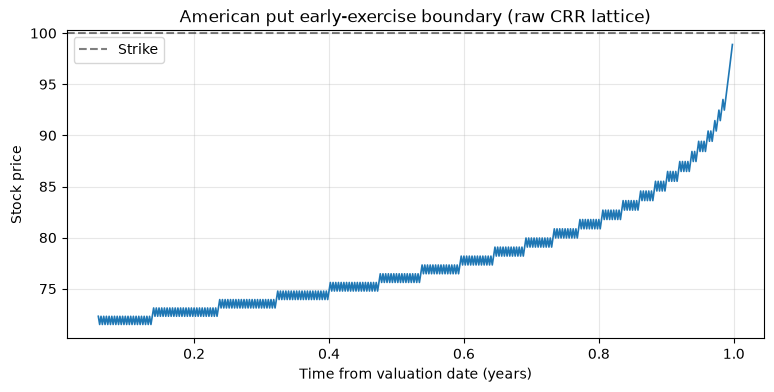

In [6]:
def exercise_boundary(tree: TreeResult, option: OptionContract) -> pd.DataFrame:
    records = []
    n_steps = len(tree.stock_nodes) - 1
    for step in range(n_steps):  # exclude expiry: it is settlement, not early exercise
        exercise_spots = tree.stock_nodes[step][tree.exercise_nodes[step]]
        if len(exercise_spots) == 0:
            boundary = np.nan
        elif option.option_type.lower() == 'put':
            boundary = float(np.max(exercise_spots))
        else:
            boundary = float(np.min(exercise_spots))
        records.append({
            'Step': step,
            'Time (years)': step * option.maturity / n_steps,
            'Raw lattice boundary': boundary,
        })
    return pd.DataFrame(records)


boundary = exercise_boundary(tree, american_put)
display(boundary.dropna().head(10))

plt.figure(figsize=(9, 4))
plt.plot(boundary['Time (years)'], boundary['Raw lattice boundary'], lw=1.2)
plt.axhline(american_put.strike, color='black', ls='--', alpha=0.5, label='Strike')
plt.xlabel('Time from valuation date (years)')
plt.ylabel('Stock price')
plt.title('American put early-exercise boundary (raw CRR lattice)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Position risk by full bump-and-revalue

Each sensitivity fully rebuilds the American-option tree, allowing the exercise policy to change after the shock. Central differences are used for Delta, Gamma, Vega, Rho, and dividend sensitivity.

Reported units are explicit:

- Delta: position P&L per one currency-unit spot move (share-equivalent);
- Gamma: change in Delta per one currency-unit spot move;
- Vega: position P&L per one volatility point;
- Rho and dividend sensitivity: position P&L per one basis point;
- Theta: position P&L for the configured number of calendar days passing.


In [7]:
def position_risk_report(
    position: Position,
    market: MarketData,
    config: TreeConfig,
    bumps: RiskBumps = RiskBumps(),
) -> pd.Series:
    option = position.option
    scale = position.scale
    spot_h = market.spot * bumps.spot_relative
    if spot_h <= 0 or market.spot - spot_h <= 0:
        raise ValueError('Spot bump must be positive and smaller than spot.')
    if bumps.volatility <= 0 or market.volatility - bumps.volatility <= 0:
        raise ValueError('Volatility bump must be positive and smaller than volatility.')
    if bumps.rate <= 0 or bumps.dividend_yield <= 0:
        raise ValueError('Rate and dividend bumps must be positive.')
    year_fraction = bumps.theta_days / bumps.day_count
    if year_fraction <= 0 or option.maturity <= year_fraction:
        raise ValueError('Theta horizon must be positive and shorter than maturity.')

    base = price_crr(option, market, config)
    spot_up = price_crr(option, replace(market, spot=market.spot + spot_h), config)
    spot_down = price_crr(option, replace(market, spot=market.spot - spot_h), config)
    vol_up = price_crr(option, replace(market, volatility=market.volatility + bumps.volatility), config)
    vol_down = price_crr(option, replace(market, volatility=market.volatility - bumps.volatility), config)
    rate_up = price_crr(option, replace(market, rate=market.rate + bumps.rate), config)
    rate_down = price_crr(option, replace(market, rate=market.rate - bumps.rate), config)
    div_up = price_crr(
        option, replace(market, dividend_yield=market.dividend_yield + bumps.dividend_yield), config
    )
    div_down = price_crr(
        option, replace(market, dividend_yield=market.dividend_yield - bumps.dividend_yield), config
    )
    rolled = price_crr(replace(option, maturity=option.maturity - year_fraction), market, config)

    return pd.Series({
        'Position PV': base * scale,
        'Delta (per 1 spot unit)': (spot_up - spot_down) / (2.0 * spot_h) * scale,
        'Gamma (per spot unit squared)': (spot_up - 2.0 * base + spot_down) / spot_h**2 * scale,
        'Vega (per 1 vol point)': (vol_up - vol_down) / (2.0 * bumps.volatility) * 0.01 * scale,
        'Rho (per 1 bp)': (rate_up - rate_down) / (2.0 * bumps.rate) * 0.0001 * scale,
        'Dividend sensitivity (per 1 bp)': (div_up - div_down) / (2.0 * bumps.dividend_yield) * 0.0001 * scale,
        f'Theta ({bumps.theta_days:g} calendar day)': (rolled - base) * scale,
    })


risk = position_risk_report(position, market, config)
display(risk.to_frame('Value'))

,Value
Position PV,"8,562.690232"
Delta (per 1 spot unit),-419.135058
Gamma (per spot unit squared),30.886551
Vega (per 1 vol point),381.083547
Rho (per 1 bp),-3.632685
Dividend sensitivity (per 1 bp),3.094307
Theta (1 calendar day),-9.779723


## 7. Greek stability

American-option Greeks can be noisy near the exercise boundary. A risk number should be considered reliable only after checking reasonable tree sizes and bump sizes.


In [8]:
def greek_stability_report(
    position,
    market,
    steps_grid=(250, 500, 1000),
    spot_bump_grid=(0.005, 0.01, 0.02),
):
    rows = []
    for steps in steps_grid:
        for spot_bump in spot_bump_grid:
            local_bumps = replace(RiskBumps(), spot_relative=spot_bump)
            values = position_risk_report(
                position, market, TreeConfig(steps=steps), local_bumps
            )
            rows.append({
                'Steps': steps,
                'Spot bump (%)': 100.0 * spot_bump,
                'Delta': values['Delta (per 1 spot unit)'],
                'Gamma': values['Gamma (per spot unit squared)'],
                'Vega per vol point': values['Vega (per 1 vol point)'],
            })
    return pd.DataFrame(rows)


greek_stability = greek_stability_report(position, market)
display(greek_stability)

,Steps,Spot bump (%),Delta,Gamma,Vega per vol point
0,250,0.500000,-420.549289,75.060492,380.943861
1,250,1.000000,-419.599394,41.286943,380.943861
2,250,2.000000,-419.000554,23.388154,380.943861
3,500,0.500000,-419.599812,55.613497,381.083547
4,500,1.000000,-419.135058,30.886551,381.083547
5,500,2.000000,-419.058261,18.067742,381.083547
6,1000,0.500000,-419.209974,41.379626,381.150718
7,1000,1.000000,-419.004025,23.421571,381.150718
8,1000,2.000000,-419.384282,18.171313,381.150718


## 8. Full-revaluation stress scenarios

Greeks are local approximations. Stress testing changes several risk factors together and completely reprices the option, including a new optimal exercise policy. Volatility shocks are entered in volatility points, rates and dividends in basis points, and spot shocks as relative returns.


In [9]:
def apply_scenario(option: OptionContract, market: MarketData, scenario: Scenario):
    shocked_market = replace(
        market,
        spot=market.spot * (1.0 + scenario.spot_pct),
        volatility=market.volatility + scenario.vol_points / 100.0,
        rate=market.rate + scenario.rate_bp / 10_000.0,
        dividend_yield=market.dividend_yield + scenario.dividend_bp / 10_000.0,
    )
    shocked_option = replace(
        option, maturity=option.maturity - scenario.days_forward / 365.0
    )
    if shocked_market.spot <= 0 or shocked_market.volatility <= 0:
        raise ValueError(f'Scenario {scenario.name!r} produces invalid spot or volatility.')
    if shocked_option.maturity <= 0:
        raise ValueError(f'Scenario {scenario.name!r} passes option maturity.')
    return shocked_option, shocked_market


def scenario_report(position, market, config, scenarios):
    base_unit = price_crr(position.option, market, config)
    rows = []
    for scenario in scenarios:
        shocked_option, shocked_market = apply_scenario(position.option, market, scenario)
        shocked_unit = price_crr(shocked_option, shocked_market, config)
        rows.append({
            'Scenario': scenario.name,
            'Spot': shocked_market.spot,
            'Volatility': shocked_market.volatility,
            'Rate': shocked_market.rate,
            'Days forward': scenario.days_forward,
            'Position PV': shocked_unit * position.scale,
            'Full-revaluation P&L': (shocked_unit - base_unit) * position.scale,
        })
    return pd.DataFrame(rows).set_index('Scenario')


scenarios = [
    Scenario('Base'),
    Scenario('Spot -10%', spot_pct=-0.10),
    Scenario('Spot +10%', spot_pct=0.10),
    Scenario('Vol +5 points', vol_points=5.0),
    Scenario('Rates +100 bp', rate_bp=100.0),
    Scenario('Equity selloff', spot_pct=-0.20, vol_points=10.0, rate_bp=-100.0, days_forward=1.0),
    Scenario('Equity rally', spot_pct=0.20, vol_points=-5.0, rate_bp=100.0, days_forward=1.0),
]

stress = scenario_report(position, market, config, scenarios)
display(stress)

,Spot,Volatility,Rate,Days forward,Position PV,Full-revaluation P&L
Scenario,,,,,,
Base,100.000000,0.250000,0.050000,0.000000,"8,562.690232",0.000000
Spot -10%,90.000000,0.250000,0.050000,0.000000,"13,661.494648","5,098.804417"
Spot +10%,110.000000,0.250000,0.050000,0.000000,"5,147.232735","-3,415.457497"
Vol +5 points,100.000000,0.300000,0.050000,0.000000,"10,468.006395","1,905.316163"
Rates +100 bp,100.000000,0.250000,0.060000,0.000000,"8,211.112659",-351.577573
Equity selloff,80.000000,0.350000,0.040000,1.000000,"23,557.140594","14,994.450362"
Equity rally,120.000000,0.200000,0.060000,1.000000,"1,468.373700","-7,094.316532"


## 9. Greek P&L explain versus full revaluation

The second-order approximation is

$$\Delta V \approx \Delta\,\Delta S + \tfrac12\Gamma(\Delta S)^2 + \text{Vega}\,\Delta\sigma + \text{Rho}\,\Delta r + \text{DivSens}\,\Delta q + \Theta\,\Delta t.$$

The residual includes higher-order terms, interactions among risk factors, and changes in the optimal exercise policy. It should grow under large stresses; this is why full revaluation remains the primary stress result.


In [10]:
def pnl_explain(
    position: Position,
    market: MarketData,
    scenario: Scenario,
    config: TreeConfig,
    bumps: RiskBumps = RiskBumps(),
) -> pd.Series:
    risk = position_risk_report(position, market, config, bumps)
    shocked_option, shocked_market = apply_scenario(position.option, market, scenario)
    base_pv = price_crr(position.option, market, config) * position.scale
    shocked_pv = price_crr(shocked_option, shocked_market, config) * position.scale

    spot_move = shocked_market.spot - market.spot
    vol_move_points = (shocked_market.volatility - market.volatility) * 100.0
    rate_move_bp = (shocked_market.rate - market.rate) * 10_000.0
    div_move_bp = (shocked_market.dividend_yield - market.dividend_yield) * 10_000.0

    components = {
        'Delta P&L': risk['Delta (per 1 spot unit)'] * spot_move,
        'Gamma P&L': 0.5 * risk['Gamma (per spot unit squared)'] * spot_move**2,
        'Vega P&L': risk['Vega (per 1 vol point)'] * vol_move_points,
        'Rho P&L': risk['Rho (per 1 bp)'] * rate_move_bp,
        'Dividend P&L': risk['Dividend sensitivity (per 1 bp)'] * div_move_bp,
        'Theta P&L': risk[f'Theta ({bumps.theta_days:g} calendar day)']
        * scenario.days_forward / bumps.theta_days,
    }
    greek_estimate = sum(components.values())
    full_revaluation = shocked_pv - base_pv
    return pd.Series({
        **components,
        'Greek-estimated P&L': greek_estimate,
        'Full-revaluation P&L': full_revaluation,
        'Unexplained P&L': full_revaluation - greek_estimate,
    }, name=scenario.name)


explain_scenario = Scenario(
    'Daily adverse move', spot_pct=-0.02, vol_points=1.0, rate_bp=-5.0, days_forward=1.0
)
explain = pnl_explain(position, market, explain_scenario, config)
display(explain.to_frame('P&L'))

,P&L
Delta P&L,838.270115
Gamma P&L,61.773103
Vega P&L,381.083547
Rho P&L,18.163425
Dividend P&L,0.000000
Theta P&L,-9.779723
Greek-estimated P&L,"1,289.510466"
Full-revaluation P&L,"1,261.694059"
Unexplained P&L,-27.816407


## 10. Portfolio aggregation

Risk is additive after every position is repriced and converted to consistent units. This example uses one underlying and one market state; a multi-underlying implementation should retain underlying, currency, expiry, and volatility-bucket dimensions before aggregation.


In [11]:
def portfolio_risk_report(positions, market, config, bumps=RiskBumps()):
    rows = []
    for item in positions:
        row = {'Position': item.name}
        row.update(position_risk_report(item, market, config, bumps).to_dict())
        rows.append(row)
    report = pd.DataFrame(rows).set_index('Position')
    report.loc['TOTAL'] = report.sum(axis=0)
    return report


portfolio = [
    position,
    Position(
        'Short 5 American calls',
        OptionContract(105.0, 0.75, 'call', 'american', multiplier=100.0),
        quantity=-5.0,
    ),
    Position(
        'Long 8 six-month puts',
        OptionContract(90.0, 0.50, 'put', 'american', multiplier=100.0),
        quantity=8.0,
    ),
]

portfolio_risk = portfolio_risk_report(portfolio, market, config)
display(portfolio_risk)

,Position PV,Delta (per 1 spot unit),Gamma (per spot unit squared),Vega (per 1 vol point),Rho (per 1 bp),Dividend sensitivity (per 1 bp),Theta (1 calendar day)
Position,,,,,,,
Long 10 American puts,"8,562.690232",-419.135058,30.886551,381.083547,-3.632685,3.094307,-9.779723
Short 5 American calls,"-3,680.163457",-243.411321,-1.295480,-170.316602,-1.551549,1.827560,9.283178
Long 8 six-month puts,"1,976.274608",-177.697634,10.129296,169.300768,-0.856756,0.779128,-10.120454
TOTAL,"6,858.801382",-840.244013,39.720368,380.067712,-6.040990,5.700996,-10.617000


## 11. Independent formulas and validation checks

The checks below cover implementation consistency and basic financial properties. Passing them is necessary, not sufficient, for production approval. An independent finite-difference implementation and market-outcome monitoring remain recommended.


In [12]:
def normal_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def black_scholes_european(option: OptionContract, market: MarketData) -> float:
    sqrt_t = math.sqrt(option.maturity)
    sigma_sqrt_t = market.volatility * sqrt_t
    d1 = (
        math.log(market.spot / option.strike)
        + (market.rate - market.dividend_yield + 0.5 * market.volatility**2) * option.maturity
    ) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t
    discount_r = math.exp(-market.rate * option.maturity)
    discount_q = math.exp(-market.dividend_yield * option.maturity)
    if option.option_type.lower() == 'call':
        return market.spot * discount_q * normal_cdf(d1) - option.strike * discount_r * normal_cdf(d2)
    return option.strike * discount_r * normal_cdf(-d2) - market.spot * discount_q * normal_cdf(-d1)


# 1) Fast and retained-lattice implementations must agree.
assert abs(price_crr(american_put, market, config) - tree.unit_price) < 1e-12

# 2) An American put cannot be worth less than the corresponding European put.
european_put = replace(american_put, style='european')
american_put_pv = price_crr(american_put, market, config)
european_put_pv = price_crr(european_put, market, config)
assert american_put_pv >= european_put_pv - 1e-12

# 3) A non-dividend-paying American call should equal its European counterpart.
no_dividend_market = replace(market, dividend_yield=0.0)
american_call = OptionContract(100.0, 1.0, 'call', 'american', multiplier=100.0)
european_call = replace(american_call, style='european')
american_call_pv = price_crr(american_call, no_dividend_market, config)
european_call_pv = price_crr(european_call, no_dividend_market, config)
assert abs(american_call_pv - european_call_pv) < 1e-9

# 4) A fine European CRR tree should be close to Black-Scholes under matching assumptions.
crr_european = price_crr(european_put, market, TreeConfig(steps=1000))
bs_european = black_scholes_european(european_put, market)
assert abs(crr_european - bs_european) < 0.01

# 5) Basic sign checks for a long put away from pathological inputs.
unit_position = Position('Validation put', american_put, quantity=1.0 / american_put.multiplier)
unit_risk = position_risk_report(unit_position, market, config)
assert unit_risk['Delta (per 1 spot unit)'] < 0.0
assert unit_risk['Gamma (per spot unit squared)'] >= -1e-10
assert unit_risk['Vega (per 1 vol point)'] > 0.0

validation = pd.Series({
    'American put unit price': american_put_pv,
    'European put unit price': european_put_pv,
    'Early-exercise premium': american_put_pv - european_put_pv,
    'CRR European price (1000 steps)': crr_european,
    'Black-Scholes European price': bs_european,
    'Absolute benchmark error': abs(crr_european - bs_european),
})
display(validation.to_frame('Value'))
print('All core validation checks passed.')

,Value
American put unit price,8.562690
European put unit price,8.222002
Early-exercise premium,0.340688
CRR European price (1000 steps),8.224419
Black-Scholes European price,8.226837
Absolute benchmark error,0.002418


All core validation checks passed.


## 12. Market data required for production use

The framework runs with the sample data above. To convert it into a market-calibrated risk process, provide:

1. valuation date and reporting currency;
2. underlying identifier and reliable spot/close;
3. each position's strike, expiry, call/put, American/European style, quantity, and multiplier;
4. risk-free discount curve by maturity and the curve convention;
5. expected discrete cash dividends with ex-dividend dates and amounts;
6. implied-volatility surface by expiry and strike or delta, preferably bid/mid/ask;
7. market option quotes for calibration and benchmark-error analysis;
8. trading calendars, day-count rules, and settlement conventions;
9. FX rates when the instrument and reporting currencies differ.

The current continuous-yield CRR tree should not be used as a substitute for an explicit discrete-dividend model around ex-dividend dates. The next model extension should add dated cash dividends and independently benchmark the resulting exercise policy against a finite-difference solver.
